# Conclusões finais

Consolidação do projeto: da caracterização dos dados à decisão de qual modelo entregar. Cada afirmação foi demonstrada em um dos notebooks anteriores.

| notebook | pergunta | resposta |
|---|---|---|
| [01](01_fase0a_osDados.ipynb) os dados | O que são e o que move a demanda? | painel de 100 SKUs × 760 dias; demanda latente; epidemia (−38%) e promoção (+30%) dominam |
| [02](02_fase0b_oCustoDoProblema.ipynb) o custo | Quanto custa o problema? | ruptura em 13,7% dos dias = **R\$ 13,3 M/ano**, contra R\$ 0,3–0,5 M de carregar estoque |
| [03](03_fase0c_cicloDeReposicao.ipynb) o ciclo | Por que acontece e o que prever? | dimensionamento: o vale do dente fica 60 un. abaixo do piso; prever o **quantil 95** |
| [05](05_fase1a_regressaoLinear.ipynb) a linear | Qual o piso, e o que o dado exige? | RMSSE **0,649**; preço vaza, erro cresce 2×, efeitos não se somam, média atende 51% |
| [06](06_fase1b_gradientBoosting.ipynb) o boosting | Interações automáticas resolvem? | sim, e vence: RMSSE **0,609**, do tamanho que a linear previu |
| [07](07_fase1c_redeNeural.ipynb) a rede | Representação densa resolve? | empata (0,613): não havia sinal a destravar |
| [09](09_fase2_hiperparametros.ipynb) os hiperparâmetros | Configurar melhor rende quanto? | 0,4% de acurácia, mas **R\$ 235 mil/ano** — o ganho é de calibração |

## A história em um parágrafo

Uma rede de varejo deixa de atender **6% da sua demanda** por falta de produto, o que vale **R\$ 13,3 milhões por ano** em vendas que nunca aparecem no faturamento. A causa não é o fornecedor nem falta de dinheiro, é **dimensionamento**: os itens de maior giro são repostos em cima da hora, sem margem. Corrigir depende de prever a demanda alta de cada item, não a média. A regressão linear estabeleceu o piso e diagnosticou o dado; cada escolha das trilhas seguintes responde a uma medição feita nela. Entre as três, o **gradient boosting é o melhor**, e ajustar seus hiperparâmetros rende mais em reais do que trocar de família de modelo. O que sobra depois disso é ruído irredutível do gerador, não sinal.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C, fase_diagramas as D
from sklearn.ensemble import HistGradientBoostingRegressor
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["axes.titleweight"]="bold"
df=C.carregar(); treino,teste=C.split(df)
print("Projeto:", df["sku"].nunique(),"SKUs ×",df.groupby("sku").size().iloc[0],"dias =",len(df),"linhas")

Projeto: 100 SKUs × 760 dias = 76000 linhas


## 1. Qual modelo prevê melhor

As três metodologias e os benchmarks, na régua idêntica.

+-----------------------+---------+-------+
| modelo                |   RMSSE |   MAE |
+=======================+=========+=======+
| naïve (lag 1)         |  0.9542 | 39.64 |
+-----------------------+---------+-------+
| naïve sazonal (lag 7) |  1.0252 | 42.78 |
+-----------------------+---------+-------+
| média do SKU          |  0.7967 | 34.04 |
+-----------------------+---------+-------+
| A · Regressão linear  |  0.6488 | 27.12 |
+-----------------------+---------+-------+
| B · Gradient Boosting |  0.6094 | 25.39 |
+-----------------------+---------+-------+
| C · MLP + embeddings  |  0.6126 | 25.52 |
+-----------------------+---------+-------+


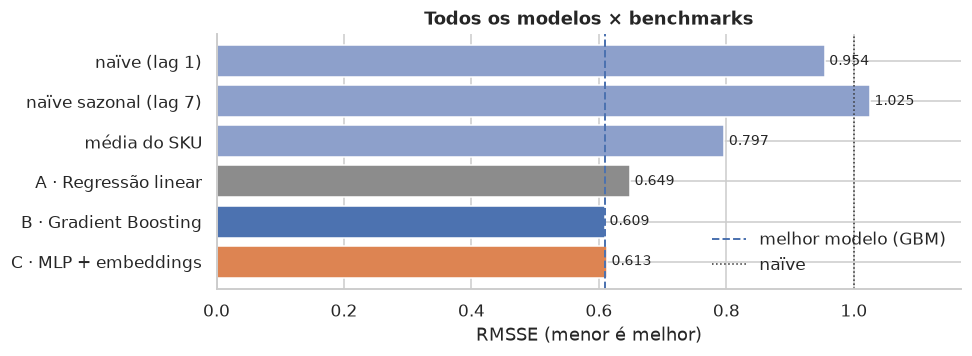

In [2]:
placar=C.benchmarks(treino,teste); linhas=[]
info=[("A · Regressão linear","A_regressaoLinear","#8C8C8C"),
      ("B · Gradient Boosting","B_gradientBoosting","#4C72B0"),
      ("C · MLP + embeddings","C_redeNeural","#DD8452")]
for nome,arq,cor in info:
    r=pd.read_csv(f"resultados/{arq}.csv",parse_dates=["data"])
    linhas.append({"modelo":nome,"RMSSE":round(C.rmsse_medio(r,"pred",treino),4),
                   "MAE":round((r["demanda"]-r["pred"]).abs().mean(),2)})
placar=pd.concat([placar,pd.DataFrame(linhas)],ignore_index=True)
print(placar.to_markdown(index=False,tablefmt="grid"))

fig,ax=plt.subplots(figsize=(9,3.4))
cor=["#8DA0CB"]*3+[c for _,_,c in info]
b=ax.barh(placar["modelo"],placar["RMSSE"],color=cor)
ax.bar_label(b,fmt="%.3f",padding=3,fontsize=9)
ax.axvline(placar["RMSSE"].min(),color="#4C72B0",lw=1.3,ls="--",label="melhor modelo (GBM)")
ax.axvline(1.0,color="#333",lw=1,ls=":",label="naïve")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("Todos os modelos × benchmarks")
ax.invert_yaxis(); ax.legend(frameon=False,loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** Todos os modelos do projeto numa escala só, RMSSE, menor é melhor. As três primeiras barras são benchmarks e as três seguintes, as trilhas.

A linear já bate os benchmarks, o gradient boosting vence e a rede empata. O ganho de 6% da linear para o boosting é o que a Trilha A previu ao medir o custo de ignorar interações; o não-ganho da rede é o que ela previu ao mostrar que a identidade do SKU não carrega sinal.

Resta a pergunta de por que o teto está aí. A resposta não está no modelo.

## 2. Por que o gradient boosting é imbatível aqui

A resposta está no dado. Três medições delimitam o teto.

(a) Teto de uma tabela-verdade perfeita (in-sample): R² = 0.57 → ~29% de ruído irredutível
(b) Heterocedasticidade: o ruído varia 3.1× conforme o contexto
(c) Correlação entre os erros das três trilhas:
+-----------------------+------------------------+-------------------------+------------------------+
|                       |   A · Regressão linear |   B · Gradient Boosting |   C · MLP + embeddings |
+=======================+========================+=========================+========================+
| A · Regressão linear  |                  1     |                   0.935 |                  0.954 |
+-----------------------+------------------------+-------------------------+------------------------+
| B · Gradient Boosting |                  0.935 |                   1     |                  0.99  |
+-----------------------+------------------------+-------------------------+------------------------+
| C · MLP + embeddings  |                  0.954 |                   0.99  |       

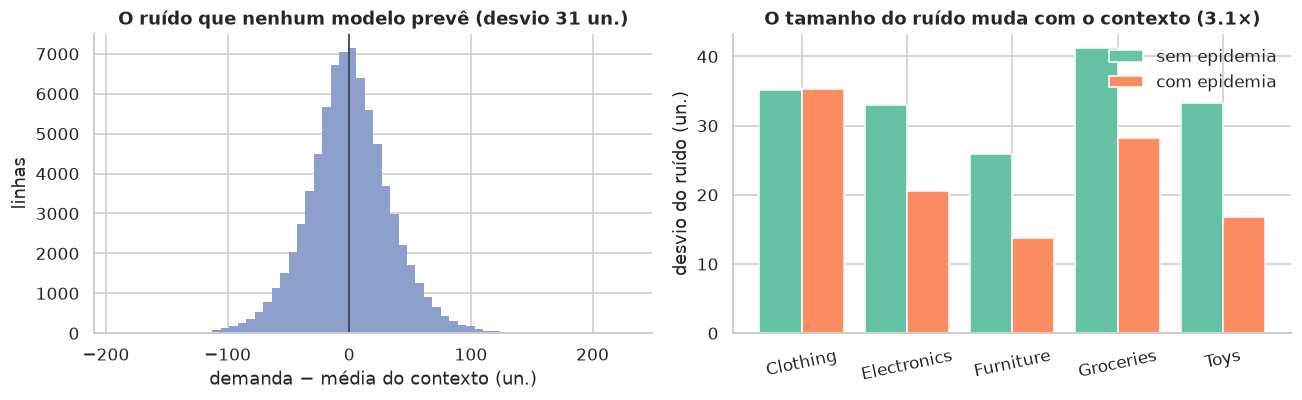

In [3]:
# (a) teto teórico: tabela-verdade por combinação exata de contexto
g=["loja","produto","clima","estacao","epidemia","promocao","desconto"]
mu=df.groupby(g)["demanda"].transform("mean")
r2=1-(df["demanda"]-mu).var()/df["demanda"].var(); ruido=(df["demanda"]-mu).std()
# (b) heterocedasticidade: o ruído varia com o contexto
g2=["loja","categoria","clima","estacao","epidemia","promocao"]
df["res"]=df["demanda"]-df.groupby(g2)["demanda"].transform("mean")
sd=df.groupby(["categoria","epidemia"])["res"].std()
sdc=df.groupby(g2)["res"].std(); razao=sdc.quantile(.9)/sdc.quantile(.1)
# (c) as três trilhas erram na mesma coisa? correlação dos resíduos de teste
er={n:(lambda r: r["demanda"]-r["pred"])(pd.read_csv(f"resultados/{a}.csv")) for n,a,_ in info}
corr=pd.DataFrame(er).corr()
print(f"(a) Teto de uma tabela-verdade perfeita (in-sample): R² = {r2:.2f} → ~{ruido/df.demanda.mean():.0%} de ruído irredutível")
print(f"(b) Heterocedasticidade: o ruído varia {razao:.1f}× conforme o contexto")
print(f"(c) Correlação entre os erros das três trilhas:\n{corr.round(3).to_markdown(tablefmt='grid')}")

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,3.8))
a1.hist(df["res"],bins=60,color="#8DA0CB",edgecolor="none"); a1.axvline(0,color="#333",lw=1)
a1.set_title(f"O ruído que nenhum modelo prevê (desvio {ruido:.0f} un.)")
a1.set_xlabel("demanda − média do contexto (un.)"); a1.set_ylabel("linhas")
sd.unstack().plot(kind="bar",ax=a2,color=["#66C2A5","#FC8D62"],width=0.8)
a2.set_title(f"O tamanho do ruído muda com o contexto ({razao:.1f}×)")
a2.set_ylabel("desvio do ruído (un.)"); a2.set_xlabel(""); a2.legend(["sem epidemia","com epidemia"],frameon=False)
a2.tick_params(axis="x",rotation=12); sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** À esquerda, a distribuição do que sobra depois de conhecer o contexto exato de cada linha — é o ruído que nenhum modelo pode prever, e sua largura é o teto do projeto. À direita, o desvio desse ruído por categoria, com e sem epidemia: **se as barras tivessem a mesma altura, o ruído seria homogêneo**; como não têm, a distribuição — e não a média — é o que ainda resta explorar.

**A tabela-verdade tem teto.** Com R² de 0,57 *in-sample*, o gerador deixou ~29% de ruído puro, que nenhum modelo prevê.

**As três trilhas erram na mesma coisa.** Boosting e MLP têm correlação de erro de 0,99, e até a linear — família completamente diferente, 6% pior — erra junto com elas (0,94 e 0,95). Quando modelos tão distintos convergem para o mesmo resíduo, o resíduo é o ruído: nem trocar de família nem combiná-las separa mais sinal.

**A brecha que sobra não é a média, é a distribuição.** O ruído é heterocedástico (3,1×), e é isso que a regressão quantílica já explora ao prever o quantil 95. A Trilha A mediu o valor dessa troca: de 51% para 94,5% de serviço, sem mudar de modelo.

Provar que um *baseline* está no teto do dado é resultado tão forte quanto batê-lo.

## 3. A rede testada

A arquitetura da Trilha C em dois níveis: macro (blocos) e micro (pesos aprendidos). O contraste com a Trilha A é o ponto: onde a linear tem 22 coeficientes legíveis, a rede tem uma topologia que só se lê como figura.


══════════════════════════════════════════════════════════════════════
  Trilha C — MLP com entity embeddings
══════════════════════════════════════════════════════════════════════


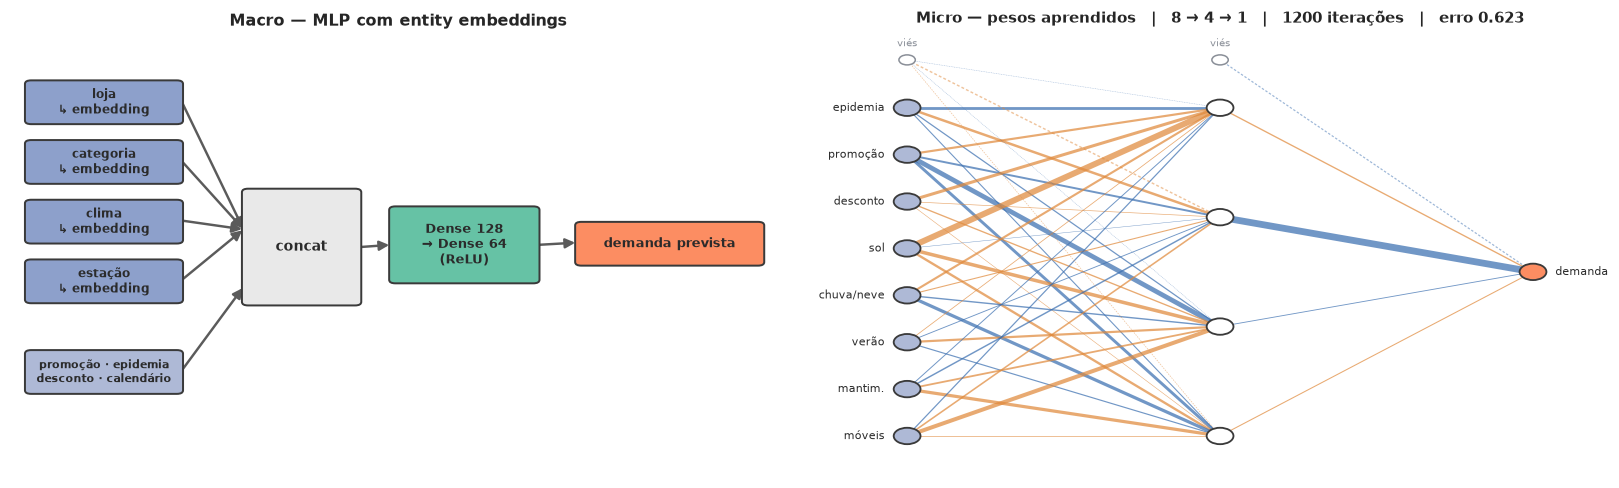

In [4]:
print("\n"+"═"*70+"\n  Trilha C — MLP com entity embeddings\n"+"═"*70)
D.painel(df,"mlp"); plt.show()

**Como ler.** À esquerda, a arquitetura da rede em blocos. À direita, os pesos aprendidos: azul positivo, laranja negativo, espessura proporcional à magnitude.

## 4. O modelo entregue

O modelo de produção é o **gradient boosting quantílico** (Trilha B), prevendo o quantil da demanda por SKU-dia, com os hiperparâmetros escolhidos na [fase 2](09_fase2_hiperparametros.ipynb). A previsão vira pedido de reposição, ajustável pelo nível de serviço **τ**.

A fase 2 ajustou no nível τ = 0,95; os mesmos valores são aplicados aos demais níveis, o que é uma extrapolação razoável dada a planura da superfície medida lá, mas fica registrada como tal.

Operação ATUAL: ruptura 13.3%, perda R$ 12.5 M/ano, capital R$ 1.92 M

+---------------------------------+----------------------+------------------+-------------------+
|                                 | Econômico (τ=0.85)   | Médio (τ=0.95)   | Seguro (τ=0.99)   |
+=================================+======================+==================+===================+
| nível de serviço-alvo (τ)       | 85%                  | 95%              | 99%               |
+---------------------------------+----------------------+------------------+-------------------+
| risco de ruptura                | 14.5%                | 4.9%             | 0.9%              |
+---------------------------------+----------------------+------------------+-------------------+
| venda perdida / ano             | R$ 6.04 M            | R$ 1.71 M        | R$ 0.34 M         |
+---------------------------------+----------------------+------------------+-------------------+
| → economia vs. hoje             | R$ 6.44 M  

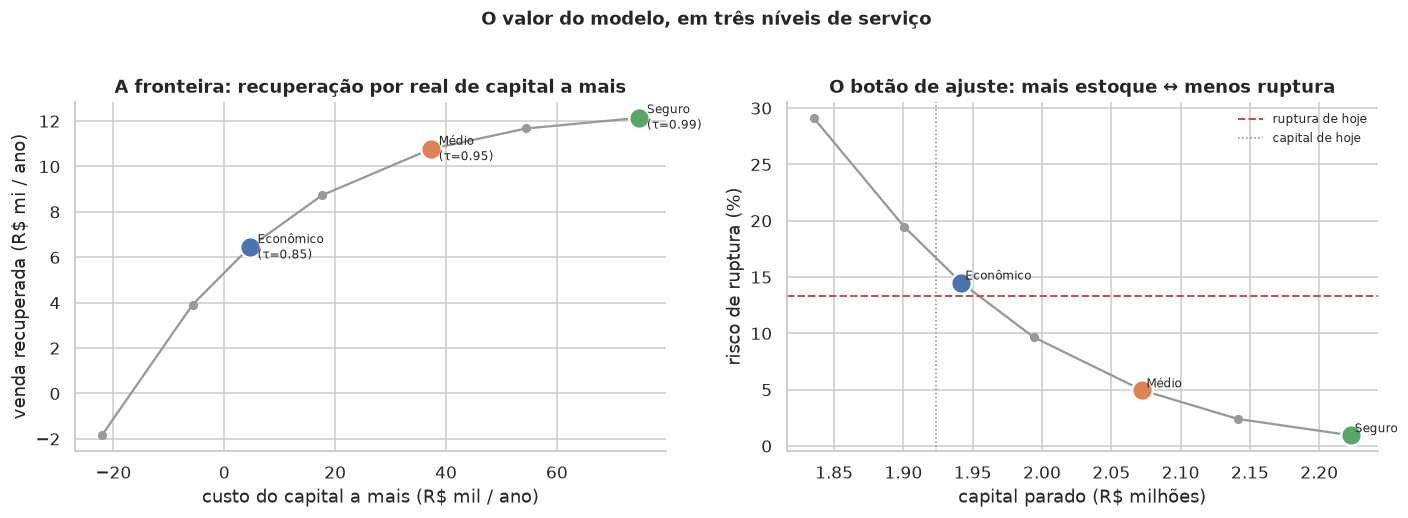


Sensibilidade — nível Médio:
  carregamento 15% a.a.: capital a mais R$ +22 mil | benefício líquido R$ 10.75 M/ano | razão perda/carregamento 43:1
  carregamento 20% a.a.: capital a mais R$ +30 mil | benefício líquido R$ 10.74 M/ano | razão perda/carregamento 32:1
  carregamento 25% a.a.: capital a mais R$ +37 mil | benefício líquido R$ 10.73 M/ano | razão perda/carregamento 26:1


In [5]:
# Política de produção: um GBM QUANTÍLICO por nível τ, com os hiperparâmetros
# escolhidos na fase 2 (busca aleatória sob validação em origem deslizante).
HIPER = dict(learning_rate=0.02, max_iter=400,
             max_depth=8, min_samples_leaf=300,
             l2_regularization=5.0, max_features=0.8)

def treina_gbm(quantil=None, seed=42):
    return HistGradientBoostingRegressor(
        loss="quantile" if quantil else "squared_error", quantile=quantil,
        categorical_features="from_dtype", early_stopping=False, random_state=seed, **HIPER
    ).fit(treino[C.FEATURES], treino["demanda"])

_cache = {}
def pq(tau):
    "Pedido no nível τ = previsão do quantil τ pelo GBM (o pedido é o piso do dente)."
    if tau not in _cache:
        _cache[tau] = np.maximum(treina_gbm(quantil=tau).predict(teste[C.FEATURES]), 0)
    return _cache[tau]

base = C.baseline_atual(df, teste)
tri = C.tres_niveis(df, teste, base, pq); frente = C.fronteira(df, teste, base, pq)
print(f"Operação ATUAL: ruptura {base['ruptura']:.1%}, perda R$ {base['perda']/1e6:.1f} M/ano, capital R$ {base['capital']/1e6:.2f} M\n")
print(C.tabela_niveis(base, tri).to_markdown(index=False, tablefmt="grid"))
C.grafico_resultados(base, frente, tri, titulo="O valor do modelo, em três níveis de serviço")

# Sensibilidade ao custo de carregamento: a conclusão não depende da premissa
med = tri[tri["nível"] == "Médio"].iloc[0]; d_cap = med["capital"] - base["capital"]
print("\nSensibilidade — nível Médio:")
for cc in [0.15, 0.20, 0.25]:
    print(f"  carregamento {cc:.0%} a.a.: capital a mais R$ {d_cap*cc/1e3:+.0f} mil | "
          f"benefício líquido R$ {(med['economia_perda'] - d_cap*cc)/1e6:.2f} M/ano | "
          f"razão perda/carregamento {base['perda']/(base['capital']*cc):.0f}:1")

**Como ler.** À esquerda, a fronteira: cada ponto é um valor de τ, o eixo horizontal é o capital adicional que ele custa e o vertical, a venda que recupera. À direita, o mesmo *trade-off* em termos operacionais. As linhas tracejadas são a operação de hoje — a distância entre elas e a curva é tudo o que o projeto entrega.

Mesmo o nível econômico já recupera milhões apenas por alocar o estoque no lugar certo; o seguro quase elimina a ruptura ao custo de ~R\$ 73 mil/ano de capital. O resultado é robusto ao custo de carregamento (15%–25%): a venda perdida domina em 26:1 a 43:1.

## 5. Visão sistêmica: o que muda na rede

As seções anteriores mediram o modelo. Esta mede a **operação com o modelo dentro** — quanto a rede inteira ganha, de onde vem esse ganho, o que é preciso para rodar e o que pode dar errado.

In [6]:
import numpy as np
r = pd.read_csv("resultados/D_gbmAjustado.csv", parse_dates=["data"])   # modelo final, previsões de teste
PRECO = df.groupby("sku")["preco"].median()          # preço estável por SKU
r["preco_ref2"] = r["sku"].map(PRECO); r["loja"] = r["sku"].str.split("-").str[0]
r["meia"] = r["sku"].map(C._reconstroi_meia_onda(df))
r["perda_R"] = np.clip(r["demanda"] - r["pred"], 0, None) * r["preco_ref2"] / C.ANOS_TESTE
r["cap_R"]   = (r["pred"] + r["meia"]) * r["preco_ref2"]

h = teste.copy(); h["preco_ref2"] = h["sku"].map(PRECO); h["loja"] = h["sku"].str.split("-").str[0]
h["perda_R"] = np.clip(h["demanda"] - h["estoque"], 0, None) * h["preco_ref2"] / C.ANOS_TESTE
h["cap_R"]   = h["estoque"] * h["preco_ref2"]

perda_h, perda_m = h["perda_R"].sum(), r["perda_R"].sum()
cap_h = h.groupby("data")["cap_R"].sum().mean(); cap_m = r.groupby("data")["cap_R"].sum().mean()
carreg = (cap_m - cap_h) * C.CUSTO_CARREGAMENTO
liquido = (perda_h - perda_m) - carreg
receita = (df["demanda"] * df["sku"].map(PRECO)).sum() / (df["data"].nunique()/365)

dre = pd.DataFrame([
    ["Venda perdida por ruptura",      f"R$ {perda_h/1e6:.2f} M", f"R$ {perda_m/1e6:.2f} M", f"R$ {(perda_h-perda_m)/1e6:+.2f} M"],
    ["Capital médio em estoque",       f"R$ {cap_h/1e6:.2f} M",   f"R$ {cap_m/1e6:.2f} M",   f"R$ {(cap_m-cap_h)/1e3:+,.0f} mil"],
    ["Custo de carregar (25% a.a.)",   f"R$ {cap_h*C.CUSTO_CARREGAMENTO/1e3:,.0f} mil", f"R$ {cap_m*C.CUSTO_CARREGAMENTO/1e3:,.0f} mil", f"R$ {carreg/1e3:+,.0f} mil"],
    ["BENEFÍCIO LÍQUIDO ANUAL",        "—", "—", f"R$ {liquido/1e6:.2f} M"]],
    columns=["linha", "operação de hoje", "com o modelo", "variação"])
print(dre.to_markdown(index=False, tablefmt="grid"))
print(f"\nReceita potencial da rede: R$ {receita/1e6:.0f} M/ano  →  o benefício equivale a {liquido/receita:.1%} da receita.")
print(f"Retorno sobre o capital adicional: cada R$ 1 a mais parado em estoque devolve R$ {liquido/(cap_m-cap_h):.0f} por ano.")

+------------------------------+--------------------+----------------+-------------+
| linha                        | operação de hoje   | com o modelo   | variação    |
+==============================+====================+================+=============+
| Venda perdida por ruptura    | R$ 12.48 M         | R$ 1.71 M      | R$ +10.77 M |
+------------------------------+--------------------+----------------+-------------+
| Capital médio em estoque     | R$ 1.92 M          | R$ 2.07 M      | R$ +149 mil |
+------------------------------+--------------------+----------------+-------------+
| Custo de carregar (25% a.a.) | R$ 481 mil         | R$ 518 mil     | R$ +37 mil  |
+------------------------------+--------------------+----------------+-------------+
| BENEFÍCIO LÍQUIDO ANUAL      | —                  | —              | R$ 10.73 M  |
+------------------------------+--------------------+----------------+-------------+

Receita potencial da rede: R$ 244 M/ano  →  o benefício equivale

**Como ler.** As duas primeiras linhas são grandezas diferentes: venda perdida é um **fluxo anual**, capital em estoque é um **estoque médio** — só o seu custo de carregamento (linha 3) vira fluxo. A última linha soma o que se recupera menos o que se gasta a mais.

O que a tabela diz é que a troca é **muito assimétrica**: imobilizar R$ 149 mil a mais devolve R$ 10,8 milhões de venda que hoje se perde. Não é um projeto de otimização fina — é destravar receita que já existe e não está sendo capturada.

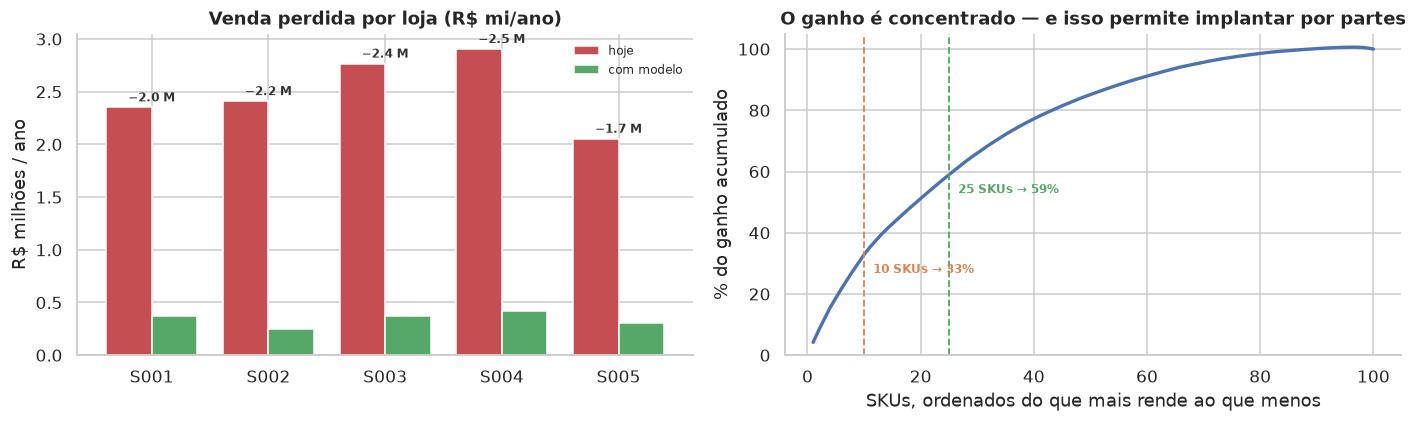

+-------------+----------------------+--------------------+--------+----------------------+
| categoria   |   perda hoje (R$ mi) |   recupera (R$ mi) |   SKUs |   R$ mil por SKU/ano |
+=============+======================+====================+========+======================+
| Groceries   |                 4.78 |               4.24 |     40 |                  106 |
+-------------+----------------------+--------------------+--------+----------------------+
| Clothing    |                 3.29 |               2.81 |     16 |                  176 |
+-------------+----------------------+--------------------+--------+----------------------+
| Electronics |                 1.94 |               1.73 |     12 |                  144 |
+-------------+----------------------+--------------------+--------+----------------------+
| Furniture   |                 1.8  |               1.37 |     18 |                   76 |
+-------------+----------------------+--------------------+--------+------------

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))

# --- por loja
gl = pd.DataFrame({"hoje": h.groupby("loja")["perda_R"].sum(), "com modelo": r.groupby("loja")["perda_R"].sum()})/1e6
gl.plot(kind="bar", ax=a1, color=["#C44E52", "#55A868"], width=0.78)
for k, (_, row) in enumerate(gl.iterrows()):
    a1.annotate(f"−{row['hoje']-row['com modelo']:.1f} M", (k, row["hoje"]), ha="center",
                xytext=(0, 4), textcoords="offset points", fontsize=8, weight="bold", color="#333")
a1.set_title("Venda perdida por loja (R$ mi/ano)"); a1.set_xlabel(""); a1.set_ylabel("R$ milhões / ano")
a1.tick_params(axis="x", rotation=0); a1.legend(frameon=False, fontsize=8)

# --- concentração do ganho entre SKUs
ganho = (h.groupby("sku")["perda_R"].sum() - r.groupby("sku")["perda_R"].sum()).sort_values(ascending=False)
acum = ganho.cumsum() / ganho.sum()
a2.plot(range(1, len(acum)+1), acum.values*100, color="#4C72B0", lw=2.2)
for n, cor in [(10, "#DD8452"), (25, "#55A868")]:
    a2.axvline(n, color=cor, lw=1.2, ls="--")
    a2.annotate(f"{n} SKUs → {acum.iloc[n-1]:.0%}", (n, acum.iloc[n-1]*100), xytext=(6, -12),
                textcoords="offset points", fontsize=8, color=cor, weight="bold")
a2.set_xlabel("SKUs, ordenados do que mais rende ao que menos"); a2.set_ylabel("% do ganho acumulado")
a2.set_title("O ganho é concentrado — e isso permite implantar por partes")
a2.set_ylim(0, 105); sns.despine(); plt.tight_layout(); plt.show()

gc = pd.DataFrame({"perda hoje (R$ mi)": h.groupby("categoria", observed=True)["perda_R"].sum()/1e6,
                   "recupera (R$ mi)": (h.groupby("categoria", observed=True)["perda_R"].sum()
                                        - r.groupby("categoria", observed=True)["perda_R"].sum())/1e6,
                   "SKUs": df.groupby("categoria", observed=True)["sku"].nunique()}).round(2)
gc["R$ mil por SKU/ano"] = (gc["recupera (R$ mi)"]*1e3/gc["SKUs"]).round(0)
print(gc.sort_values("recupera (R$ mi)", ascending=False).to_markdown(tablefmt="grid"))
print(f"\nTop 10 SKUs concentram {acum.iloc[9]:.0%} do ganho; top 25, {acum.iloc[24]:.0%}. "
      f"SKUs em que o modelo piora: {(ganho<0).sum()}.")

**Como ler o gráfico da esquerda.** Cada par de barras é uma loja: vermelha, a venda perdida hoje; verde, a que restaria com o modelo. O rótulo é a diferença.

**Como ler o gráfico da direita.** Os 100 SKUs foram ordenados do que mais rende para o que menos, e a curva acumula o ganho. Uma curva que sobe rápido e depois achata significa **ganho concentrado**; uma reta diagonal significaria ganho igualmente distribuído.

As cinco lojas ganham entre R\$ 1,7 e 2,5 milhões — o benefício **não depende de uma loja específica**, o que reduz o risco de implantação. Já entre SKUs a concentração é forte: 25 dos 100 respondem por 59% do ganho.

Por categoria, `Groceries` traz o maior volume absoluto (R\$ 4,2 M) por ter 40 SKUs, mas `Clothing` é a mais rentável **por item** (R\$ 176 mil por SKU/ano) — é onde um piloto rende mais por unidade de esforço.

### 5.1 O que é preciso para rodar

Três requisitos operacionais, medidos e não estimados.

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor as HGB
import time

# (a) custo computacional
t0 = time.time(); mprod = treina_gbm(quantil=0.95); t_treino = time.time()-t0
t0 = time.time(); _ = mprod.predict(teste[C.FEATURES]); t_prev = time.time()-t0

# (b) o modelo envelhece? previsões do modelo congelado, por idade
tt = teste.copy(); tt["p"] = np.maximum(mprod.predict(tt[C.FEATURES]), 0)
tt["idade"] = (tt["data"] - treino["data"].max()).dt.days
env = pd.DataFrame([{"idade da previsão": rot,
                     "pinball": round(C.pinball(s["demanda"].values, s["p"].values, 0.95), 3),
                     "serviço": f"{(s['demanda'].values <= s['p'].values).mean():.1%}"}
                    for a, b, rot in [(1,30,"1–30 dias"),(31,60,"31–60"),(61,90,"61–90"),(91,120,"91–120")]
                    for s in [tt[(tt.idade>=a)&(tt.idade<=b)]]])

print(f"(a) Custo: treinar {t_treino:.1f} s ({len(treino):,} linhas) · prever {t_prev*1000:.0f} ms ({len(teste):,} linhas)")
print(f"    Um laptop roda a rede inteira. Não há requisito de infraestrutura.\n")
print("(b) O modelo congelado envelhece?")
print(env.to_markdown(index=False, tablefmt="grid"))

print("\n(c) Atributos exigidos até a véspera (D−1):")
req = pd.DataFrame([{"atributo": f, "origem": ("cadastro do SKU" if f in ("loja","categoria")
                     else "calendário (determinístico)" if f.startswith(("mes","cal_"))
                     else "decisão da própria rede" if f in ("promocao","desconto")
                     else "previsão externa" if f == "clima" else "boletim / calendário")}
                   for f in C.FEATURES])
print(req.groupby("origem")["atributo"].apply(lambda s: ", ".join(s)).to_markdown(tablefmt="grid"))

(a) Custo: treinar 6.8 s (64,000 linhas) · prever 181 ms (12,000 linhas)
    Um laptop roda a rede inteira. Não há requisito de infraestrutura.

(b) O modelo congelado envelhece?
+---------------------+-----------+-----------+
| idade da previsão   |   pinball | serviço   |
+=====================+===========+===========+
| 1–30 dias           |     3.11  | 95.6%     |
+---------------------+-----------+-----------+
| 31–60               |     3.469 | 94.6%     |
+---------------------+-----------+-----------+
| 61–90               |     3.532 | 94.2%     |
+---------------------+-----------+-----------+
| 91–120              |     3.382 | 95.8%     |
+---------------------+-----------+-----------+

(c) Atributos exigidos até a véspera (D−1):
+-----------------------------+---------------------------------------------------------+
| origem                      | atributo                                                |
+=============================+=====================================

**Custo.** Treinar leva segundos e prever, milissegundos. A política inteira da rede cabe num laptop, e o artefato é **um único modelo** — a decisão de *cross-learning* da Trilha B se paga também aqui: não há 100 modelos a versionar e monitorar.

**Envelhecimento.** O modelo treinado uma vez e congelado mantém o serviço entre 94% e 96% ao longo de quatro meses, sem tendência de piora. É consequência direta do que a fase 0 mediu: a demanda **não tem memória nem tendência**, então não há deriva para acompanhar. Retreino **mensal** é folgado; trimestral já bastaria.

**Dependências de dado.** Só uma exige informação que a rede não controla: `clima` é uma previsão do tempo, com erro próprio. É o risco a examinar a seguir.

### 5.2 Riscos, medidos

O maior risco de um modelo em produção é depender de algo que, no dia, não estará lá — ou virá errado.

In [9]:
rng = np.random.default_rng(0)
PRECO_ = teste["sku"].map(PRECO).values
meia_  = teste["sku"].map(C._reconstroi_meia_onda(df)).values
base_  = C.baseline_atual(df, teste)

def liquido_de(p):
    perda = (np.clip(teste["demanda"].values - p, 0, None) * PRECO_).sum() / C.ANOS_TESTE
    cap = pd.DataFrame({"d": teste["data"].values, "v": (p + meia_) * PRECO_}).groupby("d")["v"].sum().mean()
    return (base_["perda"] - perda) - (cap - base_["capital"]) * C.CUSTO_CARREGAMENTO

cen = [{"cenário": "tudo disponível e correto", "R$ mi/ano": round(liquido_de(np.maximum(mprod.predict(teste[C.FEATURES]),0))/1e6, 2)}]
for err in [0.10, 0.20, 0.30]:
    te = teste.copy(); mask = rng.random(len(te)) < err
    te.loc[mask, "clima"] = rng.choice(list(treino["clima"].unique()), mask.sum())
    te["clima"] = te["clima"].astype(treino["clima"].dtype)
    cen.append({"cenário": f"previsão do tempo erra {err:.0%} dos dias",
                "R$ mi/ano": round(liquido_de(np.maximum(mprod.predict(te[C.FEATURES]),0))/1e6, 2)})
sem = [f for f in C.FEATURES if f != "clima"]
msem = HGB(loss="quantile", quantile=0.95, categorical_features="from_dtype",
           early_stopping=False, random_state=42, **HIPER).fit(treino[sem], treino["demanda"])
cen.append({"cenário": "sem usar clima (previsão indisponível)",
            "R$ mi/ano": round(liquido_de(np.maximum(msem.predict(teste[sem]),0))/1e6, 2)})
cen = pd.DataFrame(cen); cen["perda vs ideal"] = (cen["R$ mi/ano"] - cen["R$ mi/ano"].iloc[0]).round(2)
print(cen.to_markdown(index=False, tablefmt="grid"))

+----------------------------------------+-------------+------------------+
| cenário                                |   R$ mi/ano |   perda vs ideal |
+========================================+=============+==================+
| tudo disponível e correto              |       10.73 |             0    |
+----------------------------------------+-------------+------------------+
| previsão do tempo erra 10% dos dias    |       10.58 |            -0.15 |
+----------------------------------------+-------------+------------------+
| previsão do tempo erra 20% dos dias    |       10.47 |            -0.26 |
+----------------------------------------+-------------+------------------+
| previsão do tempo erra 30% dos dias    |       10.34 |            -0.39 |
+----------------------------------------+-------------+------------------+
| sem usar clima (previsão indisponível) |       10.62 |            -0.11 |
+----------------------------------------+-------------+------------------+


O pior cenário custa **3% do benefício**. Duas leituras práticas.

O projeto **não depende de previsão do tempo boa**: mesmo errando um dia em cada três, entrega R\$ 10,4 M dos R\$ 10,7 M. E se a previsão simplesmente não existir, treinar sem `clima` custa apenas R\$ 110 mil por ano.

O detalhe que decide a regra operacional: **errar o clima 30% das vezes é pior do que não usá-lo**. Informação errada engana o modelo; informação ausente só o empobrece. A regra que sai daí é objetiva — se a previsão do tempo não for confiável acima de ~20% de acerto marginal, é melhor desligar o atributo do que alimentá-lo com ruído.

### 5.3 Implantação sugerida

A concentração do ganho permite validar em operação real antes de comprometer a rede. Os números abaixo são calculados, não estimados.

| etapa | escopo | capital a mais | benefício líquido | o que valida |
|---|---|---|---|---|
| **piloto** | 1 loja completa (20 SKUs) | R\$ 23–38 mil | R\$ 1,7–2,5 M/ano | se a demanda prevista se confirma em prateleira real |
| **expansão** | 25 SKUs de maior ganho, 5 lojas | R\$ 135 mil | R\$ 6,31 M/ano | se o efeito se repete entre lojas |
| **rede** | 100 SKUs, 5 lojas | R\$ 149 mil | R\$ 10,73 M/ano | operação plena |

Qualquer loja serve de piloto — a mais fraca (S005) rende R\$ 1,74 M/ano e a mais forte (S004), R\$ 2,48 M. Note que a expansão já consome R\$ 135 dos R\$ 149 mil de capital: **os 25 SKUs concentrados são justamente os de giro alto**, que a fase 0c identificou como os que operam sem margem. Completar a rede depois custa quase nada em capital e ainda adiciona R\$ 4,4 M.

Três parâmetros ficam sob controle de quem opera, e é isso que torna o modelo governável:

- **τ, o nível de serviço.** O único botão de negócio. Econômico (0,85) rende R\$ 6,4 M com R\$ 5 mil de capital a mais; Seguro (0,99) rende R\$ 12,1 M com R\$ 75 mil. A escolha é de política comercial, não técnica.
- **O lote de reposição Q.** Mantido como está hoje. O modelo controla o **piso** do dente de serra, não a frequência de entrega — quem quiser mexer nos dois tem um segundo grau de liberdade ainda não explorado.
- **Os 3 SKUs em que o modelo piora.** São exceções conhecidas; devem permanecer na política atual até que se entenda o motivo, em vez de serem forçadas ao modelo.

**O que monitorar.** Duas métricas bastam. O **serviço realizado** contra o τ escolhido: se divergirem, é sinal de recalibrar — que foi exatamente o ganho da fase 2. E a **venda perdida estimada**, que é o número que justifica o projeto. Ambas se calculam com dados que a operação já registra.

**A ressalva honesta.** Todos esses valores vêm de um dataset **sintético**, cujo gerador a [fase 0a](01_fase0a_osDados.ipynb) caracterizou em detalhe. A magnitude não se transporta para uma rede real. O que se transporta é o **método**: medir a ruptura em reais, prever o quantil em vez da média, e calibrar onde fica a linha de pedido.

## 6. Veredito

**O que se entrega** é o gradient boosting da Trilha B, com os hiperparâmetros da fase 2: o mais preciso, o mais simples de operar entre os que venceram e razoavelmente interpretável. A rede foi testada com rigor e não o superou; a medição do ruído mostra por quê.

**O que a regressão linear entregou** não foi um candidato, foi o método. Dela saíram o piso, as magnitudes legíveis dos efeitos e as quatro medições que justificam cada decisão do projeto: proibir o preço, prever quantil, escolher árvores, testar *embeddings*. Sem ela, a fase 1 seria um catálogo de modelos.

**Quando uma rede venceria.** Num conjunto com memória temporal real (aqui o coeficiente da demanda de ontem é +0,10), menos ruído irredutível, sinais exógenos ricos, categóricas de cardinalidade realmente alta ou caudas assimétricas e mudanças de regime. Este dataset sintético não tem nenhuma dessas propriedades, e é só por isso que o gradient boosting permanece imbatível.

**Onde o valor apareceu.** As três alavancas foram medidas. Trocar de família de modelo rendeu R\$ 80 mil/ano entre a linear e a rede; ajustar hiperparâmetros rendeu **R\$ 235 mil/ano**; e mais dado não renderia nada, porque a curva de aprendizado satura em ~384 dias. As duas primeiras deram resultado pelo mesmo mecanismo — **calibrar onde fica a linha de pedido**, não prever melhor.

O projeto entrega um modelo e, junto, a prova de que ele está no teto do que o dado permite — além do mapa de quando valeria a pena trocá-lo.